Plot saved as 'multi_file_bar_chart.png'


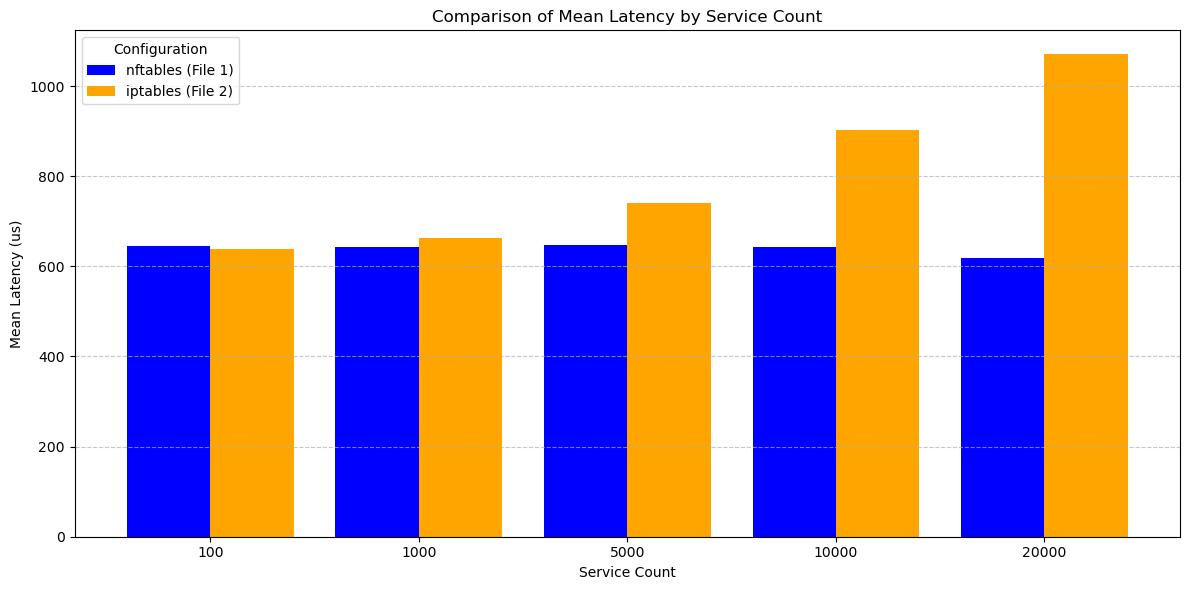

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the list of files to plot
files_to_plot = [
    {'filename': 'experiment_summary_20260212_025435.csv', 'label': 'nftables'},
    {'filename': 'experiment_summary_20260211_210132.csv', 'label': 'iptables'}
    # You can add more files here:
    # {'filename': 'another_run.csv', 'label': 'nftables'},
]

# Define colors for the labels
# If a label isn't in this list, it will default to gray
label_colors = {
    'nftables': 'blue',
    'iptables': 'orange'
}

data_frames = []
colors = []

# Load and prepare data
for i, entry in enumerate(files_to_plot):
    filename = entry['filename']
    label = entry['label']
    
    try:
        # Load the CSV
        df = pd.read_csv(filename)
        
        if 'ServiceCount' in df.columns and 'MeanLatency_us' in df.columns:
            # Create a DataFrame for this file, indexed by ServiceCount
            # We rename the 'MeanLatency_us' column to a unique name for the legend
            unique_col_name = f"{label} (File {i + 1})"
            temp_df = df[['ServiceCount', 'MeanLatency_us']].copy()
            temp_df = temp_df.set_index('ServiceCount')
            temp_df.rename(columns={'MeanLatency_us': unique_col_name}, inplace=True)
            
            data_frames.append(temp_df)
            
            # Assign the color based on the label
            colors.append(label_colors.get(label, 'gray'))
        else:
            print(f"Skipping {filename}: Required columns not found.")
            
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")

if data_frames:
    # Combine all dataframes into one side-by-side table
    combined_df = pd.concat(data_frames, axis=1)
    
    # Sort by ServiceCount (Index) so the bars are in order (100, 1000, 5000...)
    combined_df.sort_index(inplace=True)
    
    # Create the grouped bar chart
    # 'width' controls the width of the entire group of bars
    ax = combined_df.plot(kind='bar', figsize=(12, 6), color=colors, width=0.8)
    
    plt.xlabel('Service Count')
    plt.ylabel('Mean Latency (us)')
    plt.title('Comparison of Mean Latency by Service Count')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0) # Keep x-axis labels horizontal
    plt.legend(title="Configuration")
    
    plt.tight_layout()
    plt.savefig('multi_file_bar_chart.png')
    print("Plot saved as 'multi_file_bar_chart.png'")
else:
    print("No valid data found to plot.")